#***INFORMACIÓN GENERAL***

##Hotkey útiles en Colaboratory

**Algunos hotkeys útiles en Colaboratory:**

* **control+enter**: correr celda.
* **enter**: editar celda (modo edición).
* **escape**: salir del modo edición.
* **control+s**: guardar notebook.

**Fuera del modo edición se pueden utilizar los siguientes hotkeys:**
* **control+m+a**: agregar celda arriba.
* **control+m+b**: agregar celda abajo.
* **control+m+d**: borrar celda.
* **control+shift+z**: deshacer borrar celda.
* **control+m+y**: establecer celda en modo python (código).
* **control+m+m**: establecer celda en modo markdown (texto).
* **control+m+o**: mostrar/ocultar resultado.

**Cheat sheets de librerías:**

* **Jupyter notebook**: Entorno de trabajo [(Cheat sheet)](https://s3.amazonaws.com/assets.datacamp.com/blog_assets/Jupyter_Notebook_Cheat_Sheet.pdf)
* **Numpy**: librería de funciones matemáticas de alto nivel para operar con vectores y matrices [(Cheat sheet)](https://s3.amazonaws.com/assets.datacamp.com/blog_assets/Numpy_Python_Cheat_Sheet.pdf)
* **Pandas**: librería destinada al análisis de datos, permiten trabajar con datos estructurados de forma muy eficiente [(Cheat sheet)](https://github.com/pandas-dev/pandas/blob/master/doc/cheatsheet/Pandas_Cheat_Sheet.pdf)

Los cheatsheets son un resumen de las principales funciones de las librerías

Pueden revisar la documentación de cualquier módulo o función agregando un signo de pregunta y ejecutando la celda; por ejemplo:

```
#Agregar el signo de pregunta y entonces ejecutar la celda
pd.read_csv?
```



#***I. Obtención y descripción de los datos***




##***1.1. Conjunto de datos***



 **Problema del juego de tenis**<br>

Conjunto de datos simple con decisiones sobre jugar tenis


##***1.2. Descripción del conjunto de datos***

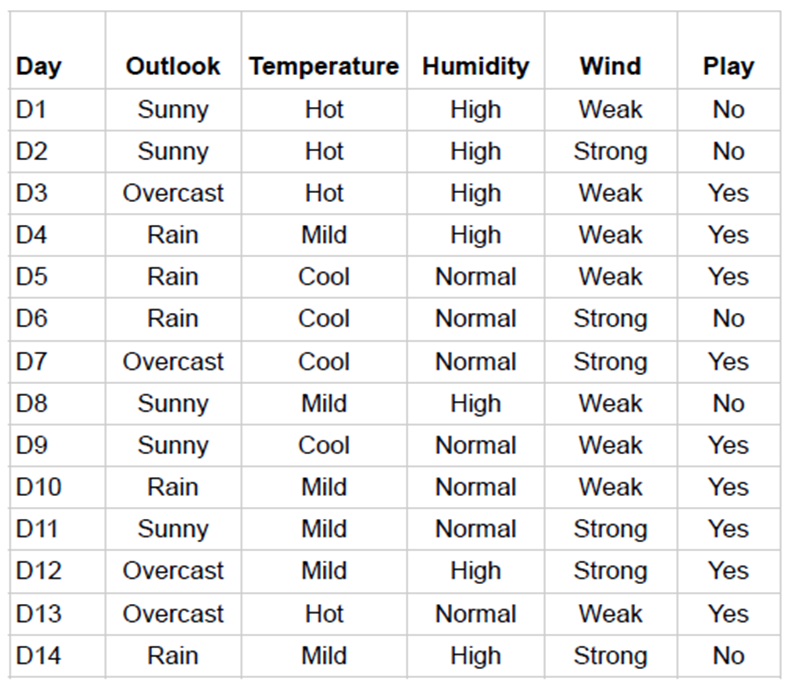

##***1.3. Lectura de datos***


### Librerías / imports

In [ ]:
#Instalaciones para graficar los árboles
!sudo apt install -y graphviz
!pip install graphviz

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
graphviz is already the newest version (2.42.2-6).
0 upgraded, 0 newly installed, 0 to remove and 45 not upgraded.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier

pd.set_option("display.max_columns", 50)

%matplotlib inline

\* La linea **%matplotlib inline**, establece el backend de matplotlib para que la salida de los comandos que generen un "plot" se muestren debajo de la celda de código que los produjo.

### Dataset

Usaremos el play tennis dataset, el cual está disponible en:
<br/>
<br/>
https://www.kaggle.com/fredericobreno/play-tennis
<br/>
<br/>
El dataset mencionado se generará al ejecutar la siguiente celda:

In [ ]:
#@title Play Tennis Dataset
%%writefile play_tennis.csv
Day,Outlook,Temperature,Humidity,Wind,Play
D1,Sunny,Hot,High,Weak,No
D2,Sunny,Hot,High,Strong,No
D3,Overcast,Hot,High,Weak,Yes
D4,Rain,Mild,High,Weak,Yes
D5,Rain,Cool,Normal,Weak,Yes
D6,Rain,Cool,Normal,Strong,No
D7,Overcast,Cool,Normal,Strong,Yes
D8,Sunny,Mild,High,Weak,No
D9,Sunny,Cool,Normal,Weak,Yes
D10,Rain,Mild,Normal,Weak,Yes
D11,Sunny,Mild,Normal,Strong,Yes
D12,Overcast,Mild,High,Strong,Yes
D13,Overcast,Hot,Normal,Weak,Yes
D14,Rain,Mild,High,Strong,No

Writing play_tennis.csv


In [ ]:
%ls

play_tennis.csv  sample_data/


In [ ]:
#Lectura del dataset
file_name = "play_tennis.csv"

#El método "read_csv" nos permite leer un archivo en formato csv
dataset = pd.read_csv(file_name)

### Revisión del dataset

In [ ]:
#Tamaño del dataset (registros, variables). En la nomenclatura de pandas es (axis 0, axis 1)
dataset.shape

(14, 6)

In [ ]:
#Vemos los primeros registros del dataset
dataset.head()

,Day,Outlook,Temperature,Humidity,Wind,Play
0,D1,Sunny,Hot,High,Weak,No
1,D2,Sunny,Hot,High,Strong,No
2,D3,Overcast,Hot,High,Weak,Yes
3,D4,Rain,Mild,High,Weak,Yes
4,D5,Rain,Cool,Normal,Weak,Yes


#II. Pre-procesamiento del dataset

##***Transformación de datos categóricos***

La transformación de datos categóricos en valores numéricos, se puede realizar haciendo uso de librerías.<br>

Para efectos de este ejercicio, en la sección de librerías, se incluyó la librería:<br>

    from sklearn.preprocessing import LabelEncoder

###Explicación de la librería $LabelEncoder$

In [ ]:
#Transformamos datos a valores numéricos
label_encoder = LabelEncoder()

data = ["A", "B", "C"]

data_to_transform = ["C", "A", "B", "C", "B"]

#Entrenamos el "encoder" con la data existente para luego proceder a realizar las transformaciones
label_encoder.fit(data)

#Visualizamos la información contenido en el "encoder" entrenado para realizar las transformaciones, a cada valor se le asigna un índica contando desde el cero
print("Información contenida en el 'encoder': {}\n".format(label_encoder.classes_))

#Transformamos datos usando el "encoder" previamente entrenado
print("Data a transformar: {}\nTransformación: {}".format(data_to_transform, label_encoder.transform(data_to_transform)))

Información contenida en el 'encoder': ['A' 'B' 'C']

Data a transformar: ['C', 'A', 'B', 'C', 'B']
Transformación: [2 0 1 2 1]


In [ ]:
# También podemos transformar datos a valores numéricos en una línea mediante
# el método "fit_transform" y realizar repetidas veces este proceso
label_encoder = LabelEncoder()

print("Primera transformación de datos:")
print("-" * 32)

data = ["C", "A", "B", "C", "B"]

#Transformamos datos usando el método "fit_transform"
print("Data a transformar: {}\nTransformación: {}\n".format(data, label_encoder.fit_transform(data)))

#Visualizamos la información contenido en el "encoder" entrenado para realizar las transformaciones, a cada valor se le asigna un índica contando desde el cero
print("Información contenida en el 'encoder': {}".format(label_encoder.classes_))

print("=" * 55)

print("Segunda transformación de datos:")
print("-" * 32)

data = ["Z", "X", "Y", "Z", "Y"]

#Transformamos datos usando el método "fit_transform"
print("Data a transformar: {}\nTransformación: {}\n".format(data, label_encoder.fit_transform(data)))

#Visualizamos la información contenido en el "encoder" entrenado para realizar las transformaciones, a cada valor se le asigna un índica contando desde el cero
print("Información contenida en el 'encoder': {}".format(label_encoder.classes_))

Primera transformación de datos:
--------------------------------
Data a transformar: ['C', 'A', 'B', 'C', 'B']
Transformación: [2 0 1 2 1]

Información contenida en el 'encoder': ['A' 'B' 'C']
Segunda transformación de datos:
--------------------------------
Data a transformar: ['Z', 'X', 'Y', 'Z', 'Y']
Transformación: [2 0 1 2 1]

Información contenida en el 'encoder': ['X' 'Y' 'Z']


###Aplicación de la librería $LabelEncoder$ en la transformación de los datos categóricos del ejercicio

In [ ]:
def preprocess_dataset(dataset):
  # -- Crear una copia del dataset
  preprocessed_dataset = dataset.copy()
  # -- Eliminar la columna "Day" porque tiene valores distintos y no contribuye a la clasificación
  if "Day" in preprocessed_dataset:
    preprocessed_dataset.drop(["Day"], axis=1, inplace=True)
  # -- Crear el objeto label_encoder, que se utilizará para la transformación de datos categóricos
  label_encoder = LabelEncoder()
  # -- Transformar las columnas que no son numéricas a números
  for column in preprocessed_dataset.columns:
    if not pd.api.types.is_numeric_dtype(preprocessed_dataset[column]):
      preprocessed_dataset[column] = label_encoder.fit_transform(preprocessed_dataset[column])

      print("Para la columna '{}', la codificación fue: {}".format(column, dict(enumerate(label_encoder.classes_))))
  # -- Retornar dataset con columnas categóricas transformadas a números
  return preprocessed_dataset

In [ ]:
#Transformamos los datos a valores numéricos
preprocessed_dataset = preprocess_dataset(dataset)

Para la columna 'Outlook', la codificación fue: {0: 'Overcast', 1: 'Rain', 2: 'Sunny'}
Para la columna 'Temperature', la codificación fue: {0: 'Cool', 1: 'Hot', 2: 'Mild'}
Para la columna 'Humidity', la codificación fue: {0: 'High', 1: 'Normal'}
Para la columna 'Wind', la codificación fue: {0: 'Strong', 1: 'Weak'}
Para la columna 'Play', la codificación fue: {0: 'No', 1: 'Yes'}


Mostrar el dataset preprocesado

In [ ]:
preprocessed_dataset.head()

,Outlook,Temperature,Humidity,Wind,Play
0,2,1,0,1,0
1,2,1,0,0,0
2,0,1,0,1,1
3,1,2,0,1,1
4,1,0,1,1,1


#III. Elegir el modelo

Considerando aspectos eminentemente pedagógicos, se utilizará el modelo de "Árboles de decisión"<br>

Para este propósito, en la sección de declaración de las librerías se incluyó la librería:<br>

    from sklearn.tree import DecisionTreeClassifier

La librería [scikit-learn](http://scikit-learn.org) ofrece un conjunto de utilidades y funciones para aplicar los algoritmos más conocidos de  machine learning. En su [documentación](http://scikit-learn.org/stable/documentation.html) se encuentran tutoriales y guías de usuario bien detalladas.

Vamos a crear un modelo de árbol de decisión usando la clase **DecisionTreeClassifier**.


#IV. Entrenamiento

##Generar variables independiente $x$ y dependiente $y$

El dataset se debe separar en variables independiente $x$ y dependiente $y$, para proceder al entrenamiento del árbol de clasificación

In [ ]:
#Separamos los datos pre procesados, en variables independientes (x) y dependientes (y)
x = preprocessed_dataset.drop(["Play"], axis=1)

y = preprocessed_dataset["Play"]

Mostrar los datos de ambas variables

In [ ]:
x.head()

,Outlook,Temperature,Humidity,Wind
0,2,1,0,1
1,2,1,0,0
2,0,1,0,1
3,1,2,0,1
4,1,0,1,1


In [ ]:
y.head()

0    0
1    0
2    1
3    1
4    1
Name: Play, dtype: int64

In [ ]:
#Revisamos la cantidad de ocurrencias por cada clase
np.unique(dataset["Play"], return_counts=True)

(array(['No', 'Yes'], dtype=object), array([5, 9]))

##Entrenar el modelo

Luego usando el método **fit** del modelo, vamos a entrenar el árbol.

In [ ]:
#Entrenamos el árbol de clasificación
model = DecisionTreeClassifier(criterion="entropy")

model.fit(x, y)

DecisionTreeClassifier(criterion='entropy')

In [ ]:
#Podemos verificar las etiquetas que tuvo que predecir nuestro árbol de clasificación
print("Etiquetas a predecir: {}".format(set(y)))

print("Etiquetas predecidas: {}".format(model.classes_))

Etiquetas a predecir: {0, 1}
Etiquetas predecidas: [0 1]


In [ ]:
#Revisamos el "accuracy" (exactitud) obtenido
model.score(x, y)

1.0

#V. Aspectos complementarios

## Visualización del árbol de clasificación

In [ ]:
from sklearn.tree import export_graphviz
from graphviz import Source
from IPython.display import SVG

classes = [(str(model_class) if isinstance(model_class, np.integer) else model_class) for model_class in model.classes_]

graph = Source(export_graphviz(model, feature_names=x.columns, class_names=classes, filled=True))

SVG(graph.pipe(format="svg"))

NameError: name 'model' is not defined

#VI. Ejercicios

##Ejercicio 1

Modificar los hiperparámetros del clasificador del árbol de decisión.

##Ejercicio 2

Implementar un "Colab" para determinar un clasificador de árboles de decisión (DecisionTreeClassifier); para lo cual determine un dataset apropiado.